## Similitud - Pares LSH

Se corre LSH mes a mes y se guardan los pares de la misma entidad, a ≤ `VENTANA_DIAS` días y con Jaccard exacto ≥ `UMBRAL`

- Por cada mes: mes + mes siguiente (pruning) → bandas LSH → candidatos → verificación exacta → parquet

- El proceso 1 del par es el más antiguo y está en el mes de análisis, así ningún par se repite entre meses

### Imports

In [1]:
import os, socket, sys, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
final_dir = proyecto / "data" / "final"
firmas_dir = proyecto / "02_Similitud" / "temp" / "a_minhash" / "firmas"
out_dir = proyecto / "02_Similitud" / "temp" / "c_pares"
out_dir.mkdir(parents=True, exist_ok=True)
pares_dir = out_dir / "pares"

- Funciones

Parámetros y funciones compartidas de `02_Similitud/funciones.ipynb`

In [3]:
ruta_funciones = str(proyecto / "02_Similitud" / "funciones.ipynb")
%run $ruta_funciones

- Figuras y tablas

In [4]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre):
    # parquet para el siguiente notebook + json para la página web
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()


def dirs_salida(out_dir):
    fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
    for d in (fig_dir, tab_dir, web_dir):
        d.mkdir(parents=True, exist_ok=True)
    return fig_dir, tab_dir, web_dir


fig_dir, tab_dir, web_dir = dirs_salida(out_dir)

- Spark

In [5]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("similitud-lsh-pares")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))     # 4g (vs 2g en 05): firmas/vectores y joins por pares pesan más que canastas
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")                                   # ~231k filas: 24 tareas bastan, las 200 por defecto quedarían casi vacías
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")                           # sin broadcast automático: los parquets descomprimidos saturaban el driver
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [ ]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

---
### 1. Carga de data

In [7]:
assert firmas_dir.exists(), f"No se encuentra {firmas_dir}; corre a_minhash.ipynb"
procesos = spark.read.parquet(str(final_dir)).select(*COLS_SIMILITUD)
firmas   = spark.read.parquet(str(firmas_dir))
N = procesos.count()

meses = [(r_["anio"], r_["mes"]) for r_ in procesos.select("anio", "mes").distinct().orderBy("anio", "mes").collect()]
print(f"{N:,} procesos | {len(meses)} meses: {meses[0]} → {meses[-1]}")

235,954 procesos | 36 meses: (2023, 1) → (2025, 12)


### 2. Procesamiento de un mes

In [8]:
def procesar_mes(anio, mes):
    proc_m   = procesos.where(filtro_meses(anio, mes))
    firmas_m = firmas.where(filtro_meses(anio, mes))
    cands    = candidatos_lsh(lsh_bandas(firmas_m), anio, mes)
    return verificar_pares(cands, proc_m, firmas_m), cands

### 3. Escritura de pares

- Se escriben en `temp/c_pares/pares`, particionados por `anio`/`mes`

- Reanudable: salta los meses ya escritos (`REINICIAR = True` para empezar de cero)

In [9]:
REINICIAR = True           # rehace los 36 meses (~1 min); False reanuda los meses ya escritos
if REINICIAR and pares_dir.exists():
    shutil.rmtree(pares_dir)

hechos = {(int(p.parent.name.split("=")[1]), int(p.name.split("=")[1])) for p in pares_dir.glob("anio=*/mes=*")} if pares_dir.exists() else set()
print(f"Meses ya procesados: {len(hechos)} de {len(meses)}")

t_total = time.time()
log_meses = []
for anio, mes in meses:
    if (anio, mes) in hechos:
        continue
    t0 = time.time()
    pares_m, cands_m = procesar_mes(anio, mes)
    cands_m = cands_m.cache(); n_c = cands_m.count()
    pares_m = pares_m.cache(); n_p = pares_m.count()
    pares_m.withColumn("anio", F.lit(anio)).withColumn("mes", F.lit(mes)).write.mode("append").partitionBy("anio", "mes").parquet(str(pares_dir))
    cands_m.unpersist(); pares_m.unpersist()
    log_meses.append({"anio": anio, "mes": mes, "candidatos": n_c, "pares": n_p, "seg": round(time.time() - t0, 1)})
    print(f"{anio}-{mes:02d}: {n_c:6,} candidatos → {n_p:5,} pares ≥ {UMBRAL}  ({time.time() - t0:5.1f} s)")
print(f"Total: {time.time() - t_total:,.0f} s")

Meses ya procesados: 0 de 36


2023-01:     65 candidatos →    33 pares ≥ 0.9  (  3.8 s)


2023-02:    460 candidatos →   168 pares ≥ 0.9  (  2.5 s)


2023-03:  3,162 candidatos → 2,213 pares ≥ 0.9  (  2.4 s)


2023-04:  1,297 candidatos →   407 pares ≥ 0.9  (  2.2 s)


...

2025-08:  4,287 candidatos → 2,937 pares ≥ 0.9  (  1.6 s)


2025-09:  1,911 candidatos →   929 pares ≥ 0.9  (  1.7 s)


2025-10:  1,898 candidatos →   997 pares ≥ 0.9  (  1.6 s)


2025-11:  1,834 candidatos →   836 pares ≥ 0.9  (  1.6 s)


2025-12:  1,509 candidatos →   737 pares ≥ 0.9  (  1.3 s)
Total: 63 s


#### a. Verificación

Todos los meses presentes, ningún par bajo `UMBRAL` ni fuera de la ventana

In [10]:
pares = spark.read.parquet(str(pares_dir))
n_pares = pares.count()
resumen = pares.groupBy("anio", "mes").count().orderBy("anio", "mes").toPandas().rename(columns={"count": "pares_90"})
assert len(resumen) == len(meses), f"Faltan meses: {set(meses) - set(zip(resumen.anio, resumen.mes))}"
assert pares.where((F.col("jaccard") < UMBRAL) | (F.col("dias_diferencia") > VENTANA_DIAS) | (F.col("dias_diferencia") < 0)).count() == 0
print(f"Pares guardados: {n_pares:,} | {len(resumen)} meses | {len(pares.columns)} columnas")
pares.printSchema()

Pares guardados: 131,473 | 36 meses | 29 columnas
root
 |-- ocid_1: string (nullable = true)
 |-- ocid_2: string (nullable = true)
 |-- entidad: string (nullable = true)
 |-- region: string (nullable = true)
 |-- periodo: string (nullable = true)
 |-- fecha_1: timestamp (nullable = true)
 |-- fecha_2: timestamp (nullable = true)
 |-- dias_diferencia: integer (nullable = true)
 |-- jaccard: double (nullable = true)
 |-- minhash_sim: double (nullable = true)
 |-- monto_final_1: double (nullable = true)
 |-- monto_final_2: double (nullable = true)
 |-- monto_suma: double (nullable = true)
 |-- tramo_1: string (nullable = true)
 |-- tramo_2: string (nullable = true)
 |-- tramo_suma: string (nullable = true)
 |-- metodo_1: string (nullable = true)
 |-- metodo_2: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- proveedor_1: string (nullable = true)
 |-- proveedor_2: string (nullable = true)
 |-- n_postores_1: integer (nullable = true)
 |-- n_postores_2: integer (nullabl

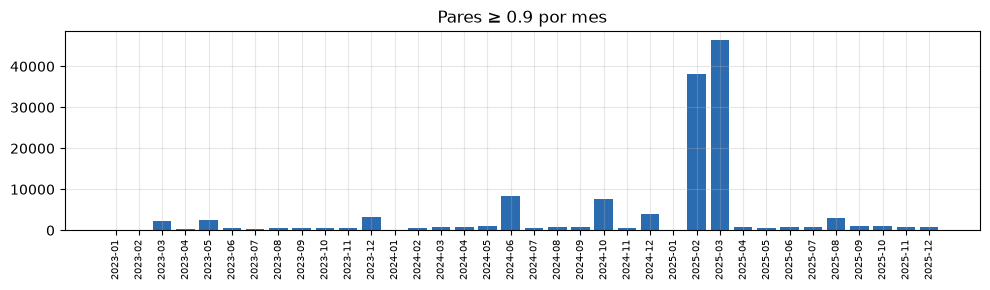

In [11]:
fig, ax = plt.subplots(figsize=(10, 3))
x = resumen["anio"].astype(str) + "-" + resumen["mes"].astype(str).str.zfill(2)
ax.bar(x, resumen["pares_90"], color="#2b6cb0"); ax.set_title(f"Pares ≥ {UMBRAL} por mes"); ax.tick_params(axis="x", rotation=90, labelsize=7)
mostrar_fig("pares_por_mes")

- 131,473 pares ≥ 0.90 en los 36 meses: LSH propuso 163,482 candidatos y la verificación exacta descartó el 20%

- 1–2 s por mes (~1 min en total): cada mes solo se cruza consigo mismo y con el siguiente

- Los picos de febrero y marzo de 2025 (38,204 y 46,306 pares, el 64% del total) son casi todos de OEFA (ver `d_entidades.ipynb`)

### 4. Escritura de resultados

- Los pares ya están en `temp/c_pares/pares` (insumo de `d_entidades`)

- Resumen por mes en `temp/c_pares/tablas` (parquet) y `web/` (json)

In [12]:
por_mes = resumen.merge(pd.DataFrame(log_meses), on=["anio", "mes"], how="left") if log_meses else resumen
escritos = {"pares_por_mes": guardar_tabla(por_mes, "pares_por_mes")}
print(f"Escrito en temp/c_pares/: {', '.join(escritos)}")

Escrito en temp/c_pares/: pares_por_mes


#### a. Verificación

In [13]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 1 tablas (parquet + json) | 1 figuras: pares_por_mes


---
### 5. Cerrar sesión

In [14]:
spark.stop()